In [1]:
# Set up the file path
import os
os.chdir('..')

In [2]:
# Import packages
from RL4CRN.iocrns.reactions import HillProduction
from RL4CRN.iocrns.reactions import MassAction
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.utils.ic import IC
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Parameter values
alpha_0 = 1                      # Basal transcription rate 
alpha = 1000                         # Maximal transcription rate
K = 1                            # Dissociation constant
n = 2                               # Hill coefficient for activation
kappa = 5                       # Translation rate
delta = 1                     # mRNA degradation rate
gamma = 5                     # Protein degradation rate

In [4]:
# Construct the reactions
rxn_0 = HillProduction(product_labels=['mA'], activator_labels=[], repressor_labels=['C'],
                       input_channels=['u_1', None, None, None], 
                       params=[alpha_0, alpha, K, n], 
                       params_controllability=[True, True, True, False])
rxn_1 = HillProduction(product_labels=['mB'], activator_labels=[], repressor_labels=['A'],
                       input_channels=[None, None, None, None], 
                       params=[alpha_0, alpha, K, n], 
                       params_controllability=[True, True, True, False])
rxn_2 = HillProduction(product_labels=['mC'], activator_labels=[], repressor_labels=['B'],
                       input_channels=[None, None, None, None], 
                       params=[alpha_0, alpha, K, n], 
                       params_controllability=[True, True, True, False])
rxn_3 = MassAction(reactant_labels=['mA'], product_labels=['mA', 'A'], input_channels=[None], params=[kappa], params_controllability=[True])
rxn_4 = MassAction(reactant_labels=['mB'], product_labels=['mB', 'B'], input_channels=[None], params=[kappa], params_controllability=[True])
rxn_5 = MassAction(reactant_labels=['mC'], product_labels=['mC', 'C'], input_channels=[None], params=[kappa], params_controllability=[True])
rxn_6 = MassAction(reactant_labels=['mA'], product_labels=[], input_channels=[None], params=[delta], params_controllability=[True])
rxn_7 = MassAction(reactant_labels=['mB'], product_labels=[], input_channels=[None], params=[delta], params_controllability=[True])
rxn_8 = MassAction(reactant_labels=['mC'], product_labels=[], input_channels=[None], params=[delta], params_controllability=[True])
rxn_9 = MassAction(reactant_labels=['A'], product_labels=[], input_channels=[None], params=[gamma], params_controllability=[True])
rxn_10 = MassAction(reactant_labels=['B'], product_labels=[], input_channels=[None], params=[gamma], params_controllability=[True])
rxn_11 = MassAction(reactant_labels=['C'], product_labels=[], input_channels=[None], params=[gamma], params_controllability=[True])

In [5]:
# Construct CRN
crn = IOCRN(reactions=[rxn_0, rxn_1, rxn_2, rxn_3, rxn_4, rxn_5, rxn_6, rxn_7, rxn_8, rxn_9, rxn_10, rxn_11], output_labels=['A', 'B', 'C'])
crn.compile()
print(crn)

Inputs: ['u_1'] 
Species: ['A', 'B', 'C', 'mA', 'mB', 'mC'] 
Output Species: ['A', 'B', 'C'] 
∅ ----> mA;  [HILLProd(b = 1u_1, Vm = 1000,    (Ka, na) = ;    (Kr, nr) = C(1, 2))]
∅ ----> mB;  [HILLProd(b = 1, Vm = 1000,    (Ka, na) = ;    (Kr, nr) = A(1, 2))]
∅ ----> mC;  [HILLProd(b = 1, Vm = 1000,    (Ka, na) = ;    (Kr, nr) = B(1, 2))]
mA ----> A + mA;  [MAK(5)]
mB ----> B + mB;  [MAK(5)]
mC ----> C + mC;  [MAK(5)]
mA ----> ∅;  [MAK(1)]
mB ----> ∅;  [MAK(1)]
mC ----> ∅;  [MAK(1)]
A ----> ∅;  [MAK(5)]
B ----> ∅;  [MAK(5)]
C ----> ∅;  [MAK(5)]


In [6]:
# List of initial conditions for IOCRN
ic = IC(names=['mA', 'A', 'mB', 'B', 'mC', 'C'], values=[[0., 1., 0., 2., 0., 5.]])
x0_list = ic.get_ic(crn)

# Inputs for IOCRN
u_list = [[1.]]

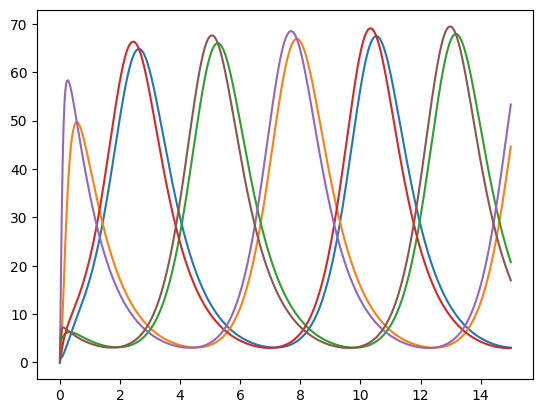

In [7]:
# Simulate dynamics
time_horizon = np.linspace(0, 15, 1000)
crn.transient_response(u_list, x0_list, time_horizon, LARGE_NUMBER=1e6)
t = crn.last_task_info['time_horizon']
x = crn.last_task_info['trajectories']
plt.plot(t, np.transpose(x[0]))
